In [18]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

### Import Library
Baris kode di atas digunakan untuk memanggil library yang memiliki fungsi untuk mengolah citra digital. NumPy digunakan untuk manipulasi matriks citra, Matplotlib berfungsi untuk memvisualisasikan data citra ke dalam bentuk gambar dan histogram, dan OpenCV digunakan secara spesifik untuk mempermudah proses konversi warna citra dan membaca file citra, seperti mengubah format menjadi grayscale.

### Membaca File Citra 
Kode di bawah ini digunakan untuk membaca, mengonversi ruang warna, dan menampilkan citra digital. Fungsi `cv.imread()` digunakan untuk memuat citra dari file `"doomsday.jpg"`. Citra tersebut dikonversi menjadi matriks grayscale melalui pemanggilan `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2GRAY` dan disimpan pada variabel `dd_gray`, serta dikonversi dari format BGR ke RGB menggunakan `cv.COLOR_BGR2RGB` untuk mengoreksi tampilan warna pada variabel `dd_rgb`. Fungsi `plt.subplot()` digunakan agar citra tampil di jendela yang sama dan `plt.imshow()` digunakan untuk menampilkan citra yang telah dibaca dan parameter `cmap = "gray"` digunakan pada citra `dd_gray` agar citranya berwarna abu.

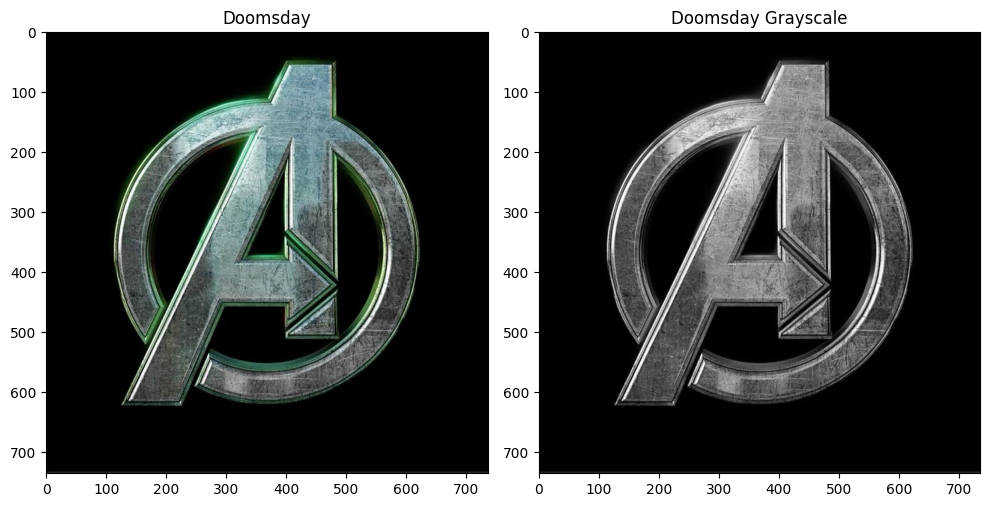

In [19]:
dd = cv.imread('doomsday.jpg')
dd_rgb = cv.cvtColor(dd, cv.COLOR_BGR2RGB)
dd_gray = cv.cvtColor(dd, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(dd_rgb); plt.title("Doomsday")
plt.subplot(1, 2, 2); plt.imshow(dd_gray, cmap='gray'); plt.title("Doomsday Grayscale")
plt.tight_layout()
plt.show()

In [20]:
def row_convolution(pad, kernel, img):
    result = np.zeros(img.shape)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            for k in range(len(kernel)):
                result[i][j] += (kernel[k] * pad[i, j + k])
    return result

def column_convolution(pad, kernel, img):
    result = np.zeros(img.shape)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            for k in range(len(kernel)):
                result[i][j] += (kernel[k] * pad[i + k, j])
    return result

### Fungsi Konvolusi
Kode di atas ini digunakan untuk mengeksekusi operasi konvolusi satu dimensi secara horizontal dan vertikal pada matriks citra. Fungsi `row_convolution` menghitung nilai konvolusi baris dengan melakukan iterasi pada setiap piksel berdasarkan dimensi `img`, lalu mengalikan setiap elemen kernel dengan elemen matriks `pad` secara horizontal, dan mengakumulasikan penjumlahannya ke dalam matriks `result`. Fungsi `column_convolution` menjalankan algoritma perulangan bersarang yang identik, namun memproses konvolusi secara kolom dengan mengalikan elemen kernel terhadap matriks `pad` pada sumbu vertikal. Kedua fungsi tersebut menginisialisasi matriks keluaran bernilai nol menggunakan `np.zeros()` yang ukurannya disesuaikan dengan dimensi citra asli, lalu mengembalikan matriks hasil operasi tersebut

In [21]:
def row_DownSampling(array):
    baris = int(array.shape[0] / 2)
    kolom = int(array.shape[1])
    result = np.zeros((baris, kolom))
    index = 0
    for i in range(baris):
        for j in range(kolom):
            result[i][j] = array[index][j]
        index += 2
    return result

def column_DownSampling(array):
    baris = int(array.shape[0])
    kolom = int(array.shape[1] / 2)
    result = np.zeros((baris, kolom))
    for i in range(baris):
        index = 0
        for j in range(kolom):
            result[i][j] = array[i][index]
            index += 2
    return result

### Fungsi Downsampling
Kode di atas ini digunakan untuk melakukan proses downsampling atau pengurangan resolusi dengan mengambil nilai piksel pada indeks genap secara manual. Fungsi `row_DownSampling` mengurangi tinggi citra menjadi setengahnya dengan cara membuat iterasi baris baru dan menyalin nilai dari array asli yang indeks barisnya melompat dua kali, sementara indeks kolom tetap dipertahankan. Fungsi `column_DownSampling` bekerja dengan prinsip serupa namun pada sumbu vertikal, yaitu dengan mengurangi lebar citra menjadi setengahnya, melakukan iterasi pada baris asli, dan menyalin elemen kolom yang indeksnya melompat dua kali untuk setiap baris tersebut. Keduanya mengembalikan matriks baru result berukuran lebih kecil yang telah diinisialisasi sebelumnya menggunakan `np.zeros()`.

In [22]:
def row_padding(image, kernel):
    pad = len(kernel) - 1
    height, width = image.shape
    new_width = width + pad
    result = np.zeros((height, new_width))
    for i in range(height):
        for j in range(width):
            result[i][j] = image[i][j]
        for j in range(pad):
            result[i][width + j] = image[i][width - 1] 
    return result

def column_padding(image, kernel):
    pad = len(kernel) - 1
    height, width = image.shape
    new_height = height + pad
    result = np.zeros((new_height, width))
    for j in range(width):
        for i in range(height):
            result[i][j] = image[i][j]
        for i in range(pad):
            result[height + i][j] = image[height - 1][j] 
    return result

### Fungsi Padding
Kode di atas ini digunakan untuk menambahkan area padding pada matriks citra dengan mereplikasi nilai piksel terluar pada sisi horizontal dan vertikal. Fungsi `row_padding` menghitung jumlah padding berdasarkan panjang kernel dikurangi satu, menginisialisasi matriks baru menggunakan `np.zeros()` dengan lebar yang diperbesar, menyalin piksel dari citra asli, lalu mengisi kolom tambahan di sisi kanan dengan menduplikasi nilai piksel terakhir dari masing-masing baris. Sementara itu, fungsi `column_padding` bekerja secara serupa pada dimensi vertikal dengan memperbesar ukuran tinggi matriks, menyalin piksel awal, dan mereplikasi nilai piksel pada baris terbawah untuk mengisi baris tambahan.

In [23]:
lowPass = [1/np.sqrt(2), 1/np.sqrt(2)]
highPass = [1/np.sqrt(2), -1/np.sqrt(2)]

### Kernel Low-pass dan High-pass
Kode di atas ini digunakan untuk mendefinisikan array kernel low-pass dan high-pass yang merupakan bagian dari algoritma Dekomposisi Wavelet Haar. Variabel `lowPass` diinisialisasi dengan dua elemen bernilai positif yang dihitung menggunakan pembagian satu dengan akar kuadrat dua melalui pemanggilan fungsi `np.sqrt(2)`. Variabel `highPass` diinisialisasi dengan konfigurasi perhitungaan yang serupa, namun elemen keduanya diubah menjadi bernilai negatif.

### Fungsi Dekomposisi Wavelet Level 1
Kode di bawah ini digunakan untuk melakukan Dekomposisi Wavelet Haar level satu secara manual untuk memecah matriks citra menjadi empat subband yaitu `LL`, `LH`, `HL`, dan `HH`. Fungsi `dekomposisi_wavelet_haar()` mendefinisikan nilai matriks filter low-pass dan high-pass, lalu mengeksekusi serangkaian operasi komputasi berurutan pada setiap subband. Proses perhitungan untuk masing-masing matriks melibatkan operasi pada sumbu horizontal melalui pemanggilan fungsi `row_padding()`, `row_convolution()`, dan `column_DownSampling()` menggunakan kombinasi kernel tertentu, yang langsung dilanjutkan dengan operasi pada sumbu vertikal melalui pemanggilan fungsi `column_padding()`, `column_convolution()`, dan `row_DownSampling()`, kemudian dilakukan normalisasi dengan fungsi `normalisasi()`. Setelah keempat matriks tersebut dikembalikan oleh fungsi menggunakan parameter input citra `dd_gray`, yang kemudian ditampilkan dan disesuaikan tata letaknya menggunakan `plt.tight_layout()`. Berdasarkan hasil uji coba, subband `LL` mempertahankan dapat mempertahanakan bentuk dari citra awal, subband `LH` mengekstrak dan menyoroti fitur garis tepi horizontal, subband `HL` menonjolkan fitur garis tepi vertikal, dan subband `HH` menampilkan fitur perubahan tepi diagonal.

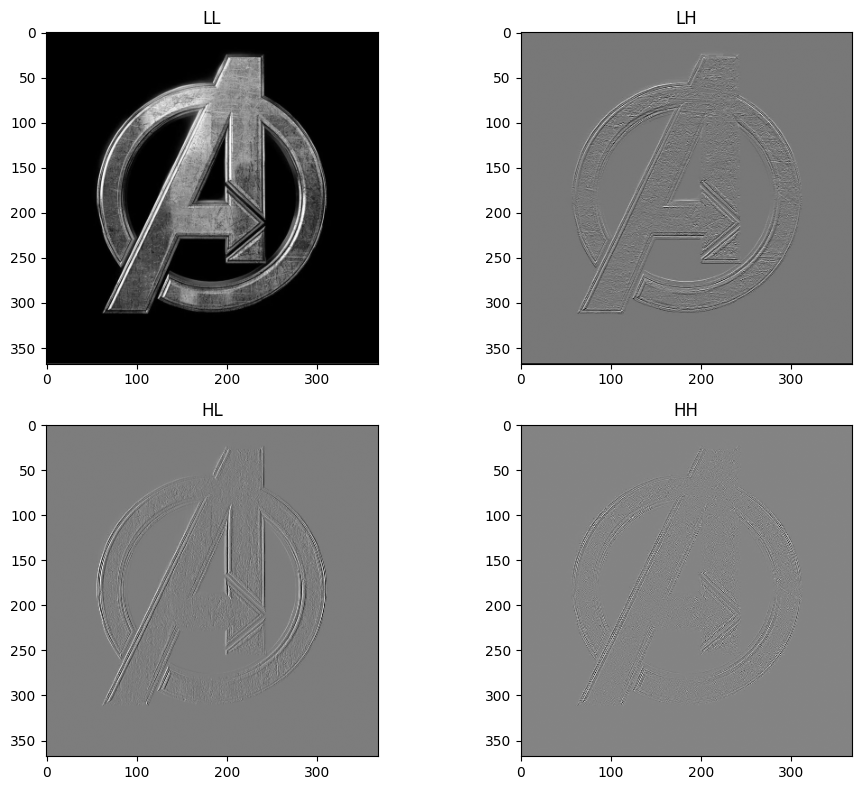

In [24]:
def normalisasi(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image)) * 255

def dekomposisi_wavelet_haar(citra):
    low = [1/np.sqrt(2), 1/np.sqrt(2)]
    high = [-1/np.sqrt(2), 1/np.sqrt(2)]

    LL_pad = row_padding(citra, low)
    LL_conv = row_convolution(LL_pad, low, citra)
    LL_ds_col = column_DownSampling(LL_conv)

    LL_pad2 = column_padding(LL_ds_col, low)
    LL_conv2 = column_convolution(LL_pad2, low, LL_ds_col)
    LL = row_DownSampling(LL_conv2)
    LL = normalisasi(LL)

    LH_pad = row_padding(citra, low)
    LH_conv = row_convolution(LH_pad, low, citra)
    LH_ds_col = column_DownSampling(LH_conv)

    LH_pad2 = column_padding(LH_ds_col, high)
    LH_conv2 = column_convolution(LH_pad2, high, LH_ds_col)
    LH = row_DownSampling(LH_conv2)
    LH = normalisasi(LH)

    HL_pad = row_padding(citra, high)
    HL_conv = row_convolution(HL_pad, high, citra)
    HL_ds_col = column_DownSampling(HL_conv)

    HL_pad2 = column_padding(HL_ds_col, low)
    HL_conv2 = column_convolution(HL_pad2, low, HL_ds_col)
    HL = row_DownSampling(HL_conv2)
    HL = normalisasi(HL)

    HH_pad = row_padding(citra, high)
    HH_conv = row_convolution(HH_pad, high, citra)
    HH_ds_col = column_DownSampling(HH_conv)

    HH_pad2 = column_padding(HH_ds_col, high)
    HH_conv2 = column_convolution(HH_pad2, high, HH_ds_col)
    HH = row_DownSampling(HH_conv2)
    HH = normalisasi(HH)

    return LL, LH, HL, HH

LL, LH, HL, HH = dekomposisi_wavelet_haar(dd_gray)

plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.title("LL")
plt.imshow(LL, cmap='gray')
plt.subplot(2, 2, 2)
plt.title("LH")
plt.imshow(LH, cmap='gray')
plt.subplot(2, 2, 3)
plt.title("HL")
plt.imshow(HL, cmap='gray')
plt.subplot(2, 2, 4)
plt.title("HH")
plt.imshow(HH, cmap='gray')
plt.tight_layout()
plt.show()

### Fungsi Threshold
Kode di bawah ini digunakan untuk melakukan segmentasi nilai piksel menjadi biner melalui operasi thresholding. Fungsi `threshold()` memulai proses dengan mengambil dimensi baris dan kolom matriks masukan, lalu menginisialisasi matriks baru bernama `canvas` yang diisi dengan nilai nol menggunakan `np.zeros_like()`. Selanjutnya, nested loop mengevaluasi setiap titik koordinat matriks secara berurutan, yaitu jika nilai piksel pada `img` lebih besar dari nilai batas, piksel pada `canvas` diubah menjadi 255, sedangkan jika bernilai lebih kecil atau sama dengan batas, nilainya ditetapkan menjadi 0. Fungsi ini kemudian diaplikasikan secara terpisah pada subband `HL`, `LH`, dan `HH` dengan nilai batas 150. Berdasarkan hasil uji coba, `HL` menonjolkan fitur frekuensi tinggi pada sumbu horizontal sehingga secara khusus mendeteksi garis tepi vertikal pada citra , sedangkan `LH` bekerja pada sumbu vertikal untuk mengekstrak garis tepi horizontal secara dominan. Sementara itu, `HH` mengekstrak fitur frekuensi dari kedua sumbu secara bersamaan, sehingga hasil visualnya menampilkan perubahan tepi diagonal, titik sudut tajam, serta tekstur detail yang lebih kompleks dari citra asal.

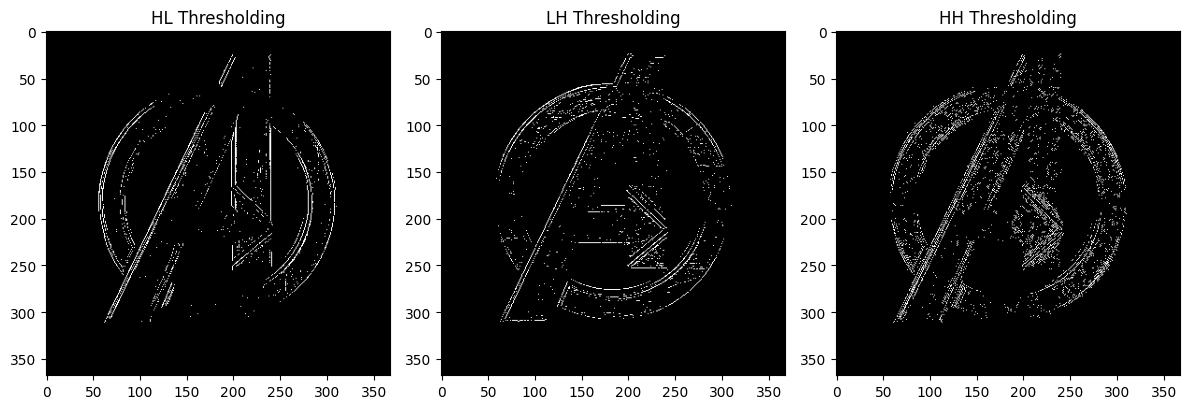

In [25]:
def threshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0
    return canvas

HL_t= threshold(HL, 150)
LH_t = threshold(LH, 150)
HH_t = threshold(HH, 150)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(HL_t, cmap='gray'); plt.title("HL Thresholding")
plt.subplot(1, 3, 2); plt.imshow(LH_t, cmap='gray'); plt.title("LH Thresholding")
plt.subplot(1, 3, 3); plt.imshow(HH_t, cmap='gray'); plt.title("HH Thresholding")
plt.tight_layout()
plt.show()

### Operasi Morfologi Closing
Kode di bawah ini digunakan untuk mengimplementasikan operasi morfologi citra secara manual. Variabel `kernel5` didefinisikan sebagai elemen penstruktur berbentuk belah ketupat berukuran 5x5. Fungsi `dilasi()` menambahkan piksel pada batas objek dengan memberikan padding pada matriks citra, melakukan iterasi, dan mengubah nilai piksel pusat menjadi 255 jika terdapat setidaknya satu nilai 255 pada area yang beririsan dengan elemen bernilai 1 pada kernel. Sebaliknya, fungsi `erosi()` mengikis batas objek dengan mengubah piksel pusat menjadi 255 hanya jika seluruh piksel pada area yang beririsan dengan elemen 1 pada kernel juga bernilai 255. Fungsi `closing()` menggabungkan kedua proses tersebut dengan mengeksekusi operasi dilasi yang langsung diikuti oleh operasi erosi. Pemanggilan fungsi `closing()` diterapkan pada subband `HL_t`, `LH_t`, dan `HH_t`. Berdasarkan hasil uji coba, `HL_closing` mempertegas kontinuitas blok piksel pada garis vertikal pembentuk logo, matriks `LH_closing` merapatkan struktur blok piksel pada garis horizontal, sementara matriks `HH_closing` memadatkan piksel-piksel pada garis diagonal serta area detail bersudut.

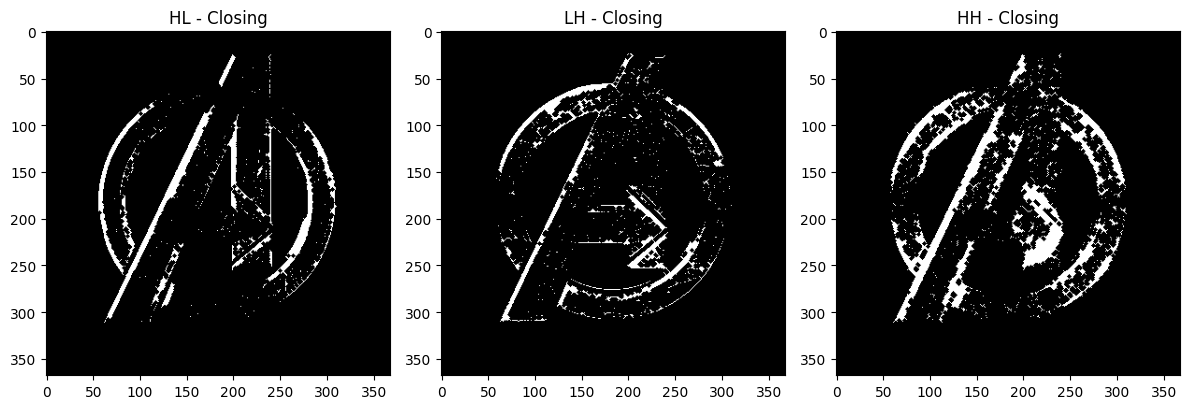

In [26]:
kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)

def dilasi(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            if np.any(region[kernel == 1] == 255):
                output[i, j] = 255
    return output

def erosi(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output = np.zeros_like(image)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            if np.all(region[kernel == 1] == 255):
                output[i, j] = 255
    return output

def closing(image, kernel):
    return erosi(dilasi(image, kernel), kernel)

HL_closing = closing(HL_t, kernel5)
LH_closing = closing(LH_t, kernel5)
HH_closing = closing(HH_t, kernel5)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(HL_closing, cmap='gray'); plt.title("HL - Closing")
plt.subplot(1, 3, 2); plt.imshow(LH_closing, cmap='gray'); plt.title("LH - Closing")
plt.subplot(1, 3, 3); plt.imshow(HH_closing, cmap='gray'); plt.title("HH - Closing")
plt.tight_layout()
plt.show()

### Fungsi Rekonstruksi
Kode di bawah ini digunakan untuk menyusun ulang empat matriks subband wavelet menjadi satu citra utuh. Fungsi `rekonstruksi()` mengeksekusi upsampling vertikal pada subband `LL` dan `LH` menggunakan `rowUpSample()`, lalu memprosesnya melalui konvolusi vertikal dengan filter low-pass dan high-pass. Kedua matriks tersebut dijumlahkan menjadi `lowBand`, dikenai upsampling horizontal, lalu dikonvolusi horizontal dengan filter low-pass untuk menghasilkan `lowResult`. Proses identik diterapkan pada `HL` dan `HH` yang menghasilkan `highBand`, dan dikonvolusi horizontal dengan filter high-pass untuk membentuk `highResult`. Kedua matriks akhir dijumlahkan dan dinormalisasi untuk membentuk matriks `hasil`. Eksekusi rekonstruksi ini dilakukan dalam tiga varian skenario yaitu citra rekonstruksi asli, `LL` bernilai 0, dan `LL` bernilai 0 dengan subband `closing`, kemudian ditampilkan. berdasarkan hasil uji coba, rekonstruksi dengan LL=0 secara eksklusif hanya mengekstrak garis tepi citra dan mengabaikan area datar. Saat menggunakan subband hasil closing, garis tepi yang terbentuk menjadi jauh lebih tebal, utuh, dan solid karena operasi morfologi tersebut berhasil menambal celah-celah noise kosong di antara piksel tepi.

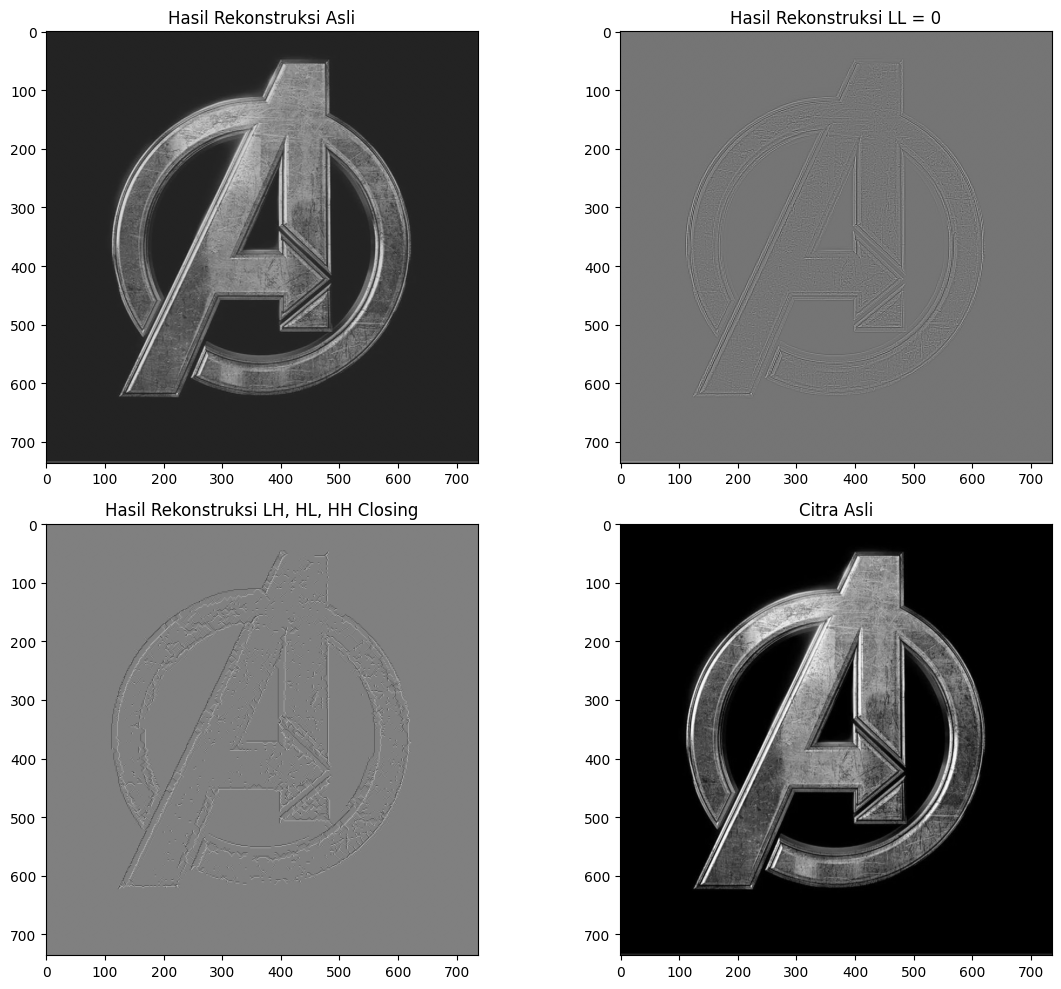

In [ ]:
def rowUpSample(image):
    rows, cols = image.shape
    upsampled = np.zeros((rows * 2, cols))
    for i in range(rows):
        for j in range(cols):
            upsampled[2 * i][j] = image[i][j]
            upsampled[2 * i + 1][j] = image[i][j]
    return upsampled

def columnUpSample(image):
    rows, cols = image.shape
    upsampled = np.zeros((rows, cols * 2))
    for i in range(rows):
        for j in range(cols):
            upsampled[i][2 * j] = image[i][j]
            upsampled[i][2 * j + 1] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH):
    LL_up = rowUpSample(LL)
    LH_up = rowUpSample(LH)
    padLL = column_padding(LL_up, lowPass)
    convLL = column_convolution(padLL, lowPass, LL_up)
    padLH = column_padding(LH_up, highPass)
    convLH = column_convolution(padLH, highPass, LH_up)
    lowBand = convLL + convLH
    lowBand = columnUpSample(lowBand)
    padLow = row_padding(lowBand, lowPass)
    lowResult = row_convolution(padLow, lowPass, lowBand)
    HL_up = rowUpSample(HL)
    HH_up = rowUpSample(HH)
    padHL = column_padding(HL_up, lowPass)
    convHL = column_convolution(padHL, lowPass, HL_up)
    padHH = column_padding(HH_up, highPass)
    convHH = column_convolution(padHH, highPass, HH_up)
    highBand = convHL + convHH
    highBand = columnUpSample(highBand)
    padHigh = row_padding(highBand, highPass)
    highResult = row_convolution(padHigh, highPass, highBand)
    result = lowResult + highResult
    return normalisasi(result)

LL0 = np.zeros_like(LL)
hasil_rekonstruksi = rekonstruksi(LL, LH, HL, HH)
rek0 = rekonstruksi(LL0, LH, HL, HH)
rek0c = rekonstruksi(LL0, LH_closing, HL_closing, HH_closing)

plt.figure(figsize=(12,10))
plt.subplot(2,2,1); plt.imshow(hasil_rekonstruksi, cmap='gray'); plt.title('Hasil Rekonstruksi Asli')
plt.subplot(2,2,2); plt.imshow(rek0, cmap='gray'); plt.title('Hasil Rekonstruksi LL = 0')
plt.subplot(2,2,3); plt.imshow(rek0c, cmap='gray'); plt.title('Hasil Rekonstruksi LH, HL, HH Closing')
plt.subplot(2,2,4); plt.imshow(dd_gray, cmap='gray'); plt.title('Citra Asli')
plt.tight_layout()
plt.show()